# PSO for Economic Dispatch with Valve-Point Effects

This notebook demonstrates a **2-D unconstrained nonlinear optimization** problem with **Particle Swarm Optimization (PSO)**.

The generator fuel-cost model is

$$ C_i(P_i)=a_i+b_iP_i+c_iP_i^2+ \left|e_i\sin\left[f_i(P_i^{\min}-P_i)\right]\right|. $$

The sinusoidal term produces the **valve-point effect**, creating ripples and multiple local minima. It assumes that the actual fuel consumption/cost does not increase perfectly smoothly with generator output because sequential steam-valve opening introduces ripples into the heat-rate characteristic.

Our goal is to minimize the total hourly fuel cost of generation from 2 generators, given the above fuel-cost model.

We solve two problems:

1. **Without a demand penalty**
2. **With a quadratic demand-mismatch penalty**

For each section, we:
- visualize the 2-D objective surface,
- solve it using `sko.PSO.PSO`,
- report the optimum,
- plot the swarm at six representative iterations.

References:
* Prakash *et al.* (2024). Minimization of fuel cost for generator systems with valve point effect using modified PSO. *Franklin Open*, 7(2024), 100090. DOI: [10.1016/j.fraope.2024.100090](https://doi.org/10.1016/j.fraope.2024.100090)
* Abdullah *et al.* (2012). Economic dispatch with valve point effect using iteration particle swarm optimization. 2012 47th International Universities Power Engineering Conference (UPEC). DOI: [10.1109/UPEC.2012.6398693](https://ieeexplore.ieee.org/document/6398693)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sko.PSO import PSO

np.random.seed(42)


## Generator data

Decision variables:

* $P_1$ = power output of generator 1.
* $P_2$ = power output of generator 2.

Fixed parameters:
* $a_i, b_i, c_i, d_i, e_i, f_i$ = cost function parameters for generator $i$.
* $P^{min}_i$ = minimum power output of generator $i$.
* $P^{max}_i$ = maximum power output of generator $i$.

In [2]:
gen1 = {
    "Pmin": 50.0, "Pmax": 200.0,
    "a": 300.0, "b": 2.0, "c": 0.0015,
    "e": 120.0, "f": 0.12
}

gen2 = {
    "Pmin": 40.0, "Pmax": 180.0,
    "a": 250.0, "b": 2.2, "c": 0.0018,
    "e": 100.0, "f": 0.14
}

def generator_cost(P, g):
    return g["a"] + g["b"]*P + g["c"]*P**2 + np.abs(g["e"] * np.sin(g["f"]*(g["Pmin"] - P)))

def total_cost(P1, P2):
    return generator_cost(P1, gen1) + generator_cost(P2, gen2)

# Grid used only for visualization
P1_vals = np.linspace(gen1["Pmin"], gen1["Pmax"], 300)
P2_vals = np.linspace(gen2["Pmin"], gen2["Pmax"], 300)
P1_grid, P2_grid = np.meshgrid(P1_vals, P2_vals)

lb = [gen1["Pmin"], gen2["Pmin"]]
ub = [gen1["Pmax"], gen2["Pmax"]]

# PSO settings
n_particles = 30
n_iterations = 60
w = 0.7
c1 = 1.5
c2 = 1.5

# 1. Without demand penalty

We first minimize only total fuel cost in operating the generators:

$$ \min_{P_1,P_2} J_1(P_1,P_2) = C_1(P_1)+C_2(P_2) $$

There is no requirement to satisfy a power demand.

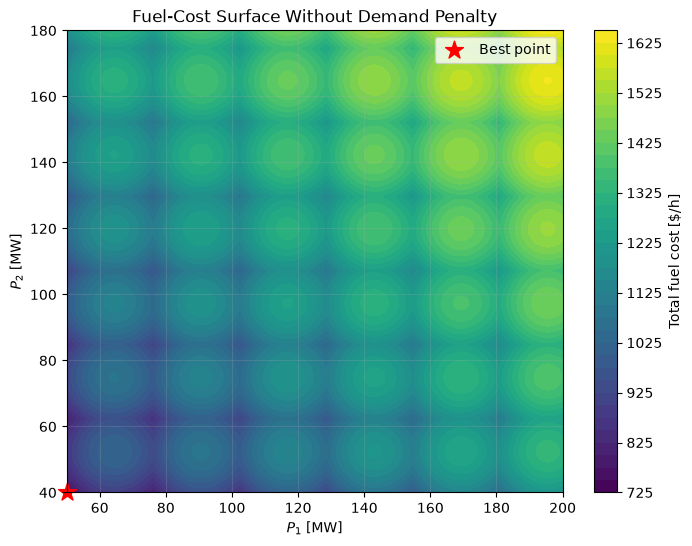

In [3]:
J1 = total_cost(P1_grid, P2_grid)

# Get the best point out of all gridded points
idx = np.unravel_index(np.argmin(J1), J1.shape)
grid_best_1 = np.array([P1_grid[idx], P2_grid[idx]])

plt.figure(figsize=(8,6))
cs = plt.contourf(P1_grid, P2_grid, J1, levels=40)
plt.colorbar(cs, label="Total fuel cost [$/h]")

plt.scatter(grid_best_1[0], grid_best_1[1], color='r',
    marker="*", s=180, label="Best point", clip_on=False)

plt.xlabel(r"$P_1$ [MW]")
plt.ylabel(r"$P_2$ [MW]")
plt.title("Fuel-Cost Surface Without Demand Penalty")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [4]:
def objective_1(x):
    P1, P2 = x
    return total_cost(P1, P2)

np.random.seed(42)

pso1 = PSO(func=objective_1, n_dim=2,
    pop=n_particles, max_iter=n_iterations,
    lb=lb, ub=ub, w=w, c1=c1, c2=c2)

# Record swarm position at every iteration
pso1.record_mode = True

best_x_1, best_y_1 = pso1.run()

best_x_1 = np.asarray(best_x_1).ravel()
best_y_1 = float(np.asarray(best_y_1).ravel()[0])

print("PSO result — no demand penalty")
print(f"P1* = {best_x_1[0]:.4f} MW")
print(f"P2* = {best_x_1[1]:.4f} MW")
print(f"Total generation = {best_x_1.sum():.4f} MW")
print(f"Minimum fuel cost = {best_y_1:.4f} $/h")


PSO result — no demand penalty
P1* = 50.0000 MW
P2* = 40.0000 MW
Total generation = 90.0000 MW
Minimum fuel cost = 744.6300 $/h



## PSO snapshots

The panels below show the recorded swarm positions at representative iterations $ 1, 5, 15, 60.$

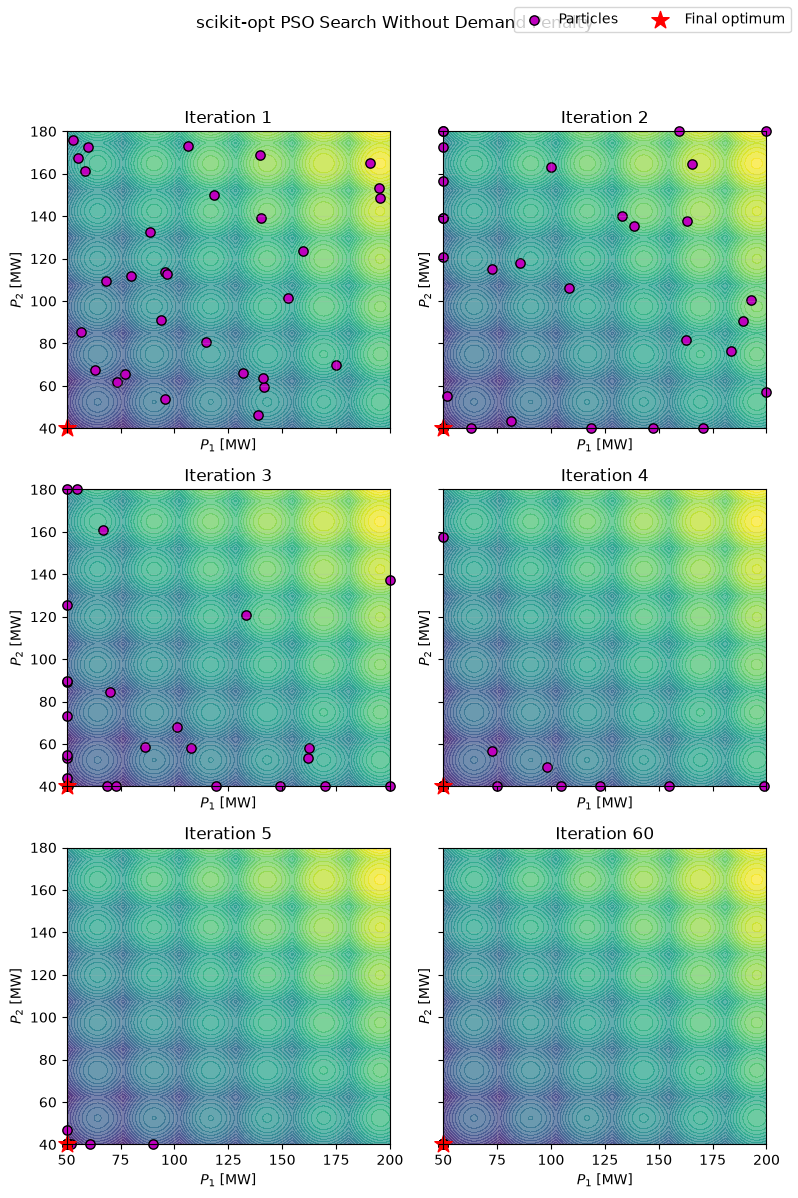

In [5]:
history1 = pso1.record_value["X"]
snapshots = [1, 2, 3, 4, 5, 60]

fig, axes = plt.subplots(3, 2,figsize=(8,12), sharex=True, sharey=True)

for ax, it in zip(axes.ravel(), snapshots):
    ax.contourf(P1_grid, P2_grid, J1, alpha=0.7, levels=50)
    swarm = np.asarray(history1[min(it-1, len(history1)-1)])

    ax.scatter(swarm[:,0], swarm[:,1], color='m', clip_on=False,
        s=45, edgecolors='k', label="Particles")

    ax.scatter(best_x_1[0], best_x_1[1], clip_on=False,
        marker="*", color='r', s=170, label="Final optimum")

    ax.set_title(f"Iteration {it}")
    ax.set_xlabel(r"$P_1$ [MW]")
    ax.set_ylabel(r"$P_2$ [MW]")
    ax.grid(alpha=0.2)

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2)
fig.suptitle("scikit-opt PSO Search Without Demand Penalty", y=0.99)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


### Interpretation

Without a demand requirement, the optimizer simply searches for the least expensive generator outputs.

The valve-point terms make the surface nonlinear and rippled, but there is no incentive to produce a prescribed amount of electricity.


# 2. With demand penalty

Suppose total demand is $ D=300\ \mathrm{MW}.$ In the current version, `scikit-opt` does not accept equality constraints. 

Instead of imposing $ P_1+P_2=D$ as an equality constraint, we add a quadratic mismatch penalty:

$$ J_2(P_1,P_2) = C_1(P_1)+C_2(P_2) + \lambda(P_1+P_2-D)^2 $$

where $\lambda$ determines how strongly demand mismatch is penalized. 


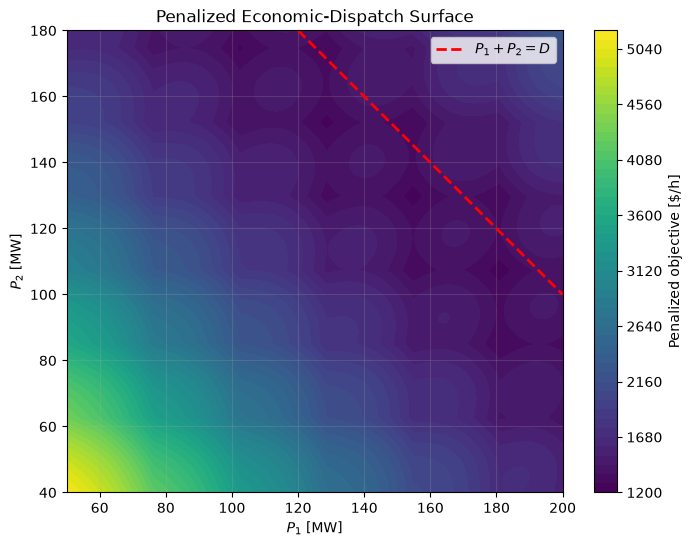

In [6]:
D = 300.0
lam = 0.1

def penalized_cost(P1, P2):
    mismatch = P1 + P2 - D
    return total_cost(P1, P2) + lam*mismatch**2

J2 = penalized_cost(P1_grid, P2_grid)

# Demand-balance line for visualization
P1_line = np.linspace(
    max(gen1["Pmin"], D-gen2["Pmax"]),
    min(gen1["Pmax"], D-gen2["Pmin"]),
    300
)
P2_line = D - P1_line

plt.figure(figsize=(8,6))
cs = plt.contourf(P1_grid, P2_grid, J2, levels=50)
plt.colorbar(cs, label="Penalized objective [$/h]")

plt.plot(P1_line, P2_line, "r--",
    linewidth=2, label=r"$P_1+P_2=D$")

plt.xlabel(r"$P_1$ [MW]")
plt.ylabel(r"$P_2$ [MW]")
plt.title("Penalized Economic-Dispatch Surface")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [7]:
def objective_2(x):
    P1, P2 = x
    return penalized_cost(P1, P2)

np.random.seed(42)

pso2 = PSO(func=objective_2, n_dim=2, pop=n_particles, 
           max_iter=n_iterations, lb=lb, ub=ub, w=w, c1=c1, c2=c2)

pso2.record_mode = True

best_x_2, best_y_2 = pso2.run()

best_x_2 = np.asarray(best_x_2).ravel()
best_y_2 = float(np.asarray(best_y_2).ravel()[0])

P1_opt, P2_opt = best_x_2

fuel_cost = total_cost(P1_opt, P2_opt)
mismatch = P1_opt + P2_opt - D
penalty = lam*mismatch**2

print("PSO result — with demand penalty")
print(f"P1* = {P1_opt:.4f} MW")
print(f"P2* = {P2_opt:.4f} MW")
print(f"Total generation = {P1_opt + P2_opt:.4f} MW")
print(f"Demand = {D:.4f} MW")
print(f"Mismatch = {mismatch:.6f} MW")
print(f"Fuel cost = {fuel_cost:.4f} $/h")
print(f"Penalty = {penalty:.4f} $/h")
print(f"Penalized objective = {best_y_2:.4f} $/h")

PSO result — with demand penalty
P1* = 154.7239 MW
P2* = 129.7602 MW
Total generation = 284.4841 MW
Demand = 300.0000 MW
Mismatch = -15.515882 MW
Fuel cost = 1211.2031 $/h
Penalty = 24.0743 $/h
Penalized objective = 1235.2773 $/h


## PSO snapshots

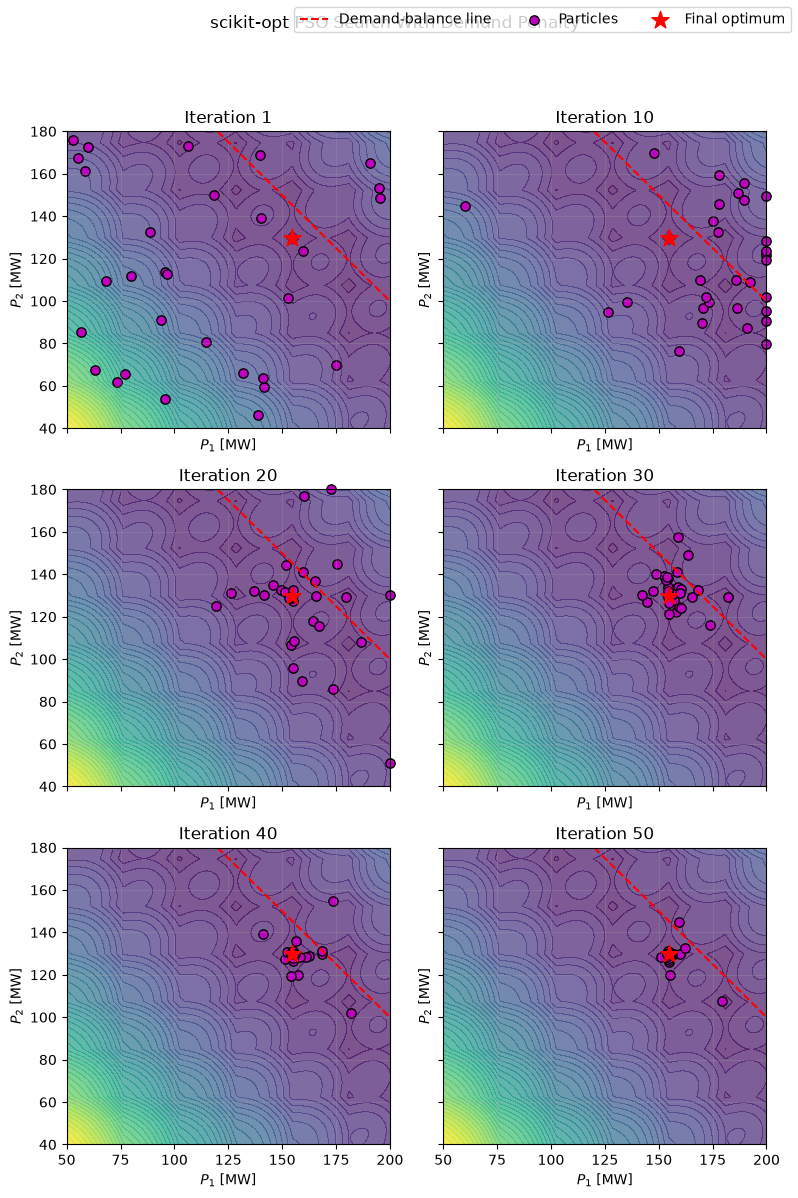

In [8]:
history2 = pso2.record_value["X"]
snapshots = [1, 10, 20, 30, 40, 50]

fig, axes = plt.subplots(3, 2, figsize=(8,12),
    sharex=True, sharey=True)

for ax, it in zip(axes.ravel(), snapshots):
    ax.contourf(P1_grid, P2_grid, J2, levels=50, alpha=0.7)

    ax.plot(P1_line, P2_line, "r--",
        linewidth=1.5, label="Demand-balance line")

    swarm = np.asarray(history2[min(it-1, len(history2)-1)])

    ax.scatter(swarm[:,0], swarm[:,1], color='m',
               s=45, edgecolors='k', clip_on=False, label="Particles")

    ax.scatter(P1_opt, P2_opt, color='r', marker="*", 
               clip_on=False, s=170, label="Final optimum")

    ax.set_title(f"Iteration {it}")
    ax.set_xlabel(r"$P_1$ [MW]")
    ax.set_ylabel(r"$P_2$ [MW]")
    ax.grid(alpha=0.2)

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=3)
fig.suptitle("scikit-opt PSO Search With Demand Penalty", y=0.99)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

## Display the PSO performance across iterations  

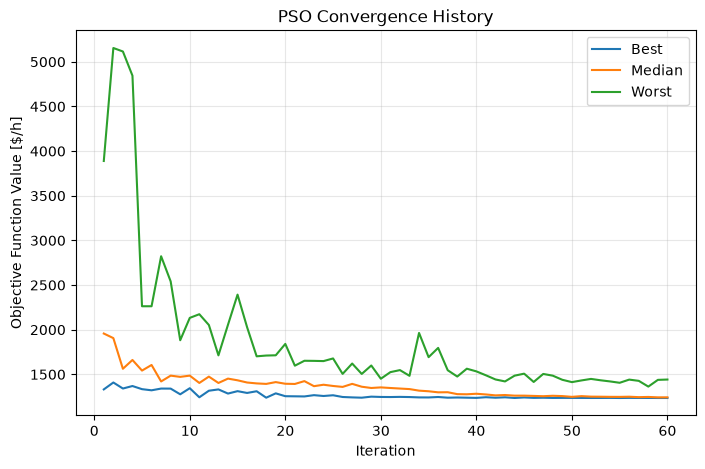

In [9]:
history = pso2.record_value["X"]

best_history = []
median_history = []
worst_history = []

for swarm in history:
    
    swarm = np.asarray(swarm)
    
    # Evaluate the objective function for all particles
    objective_values = np.array([
        objective_2(x) for x in swarm
    ])
    
    # Record population statistics
    best_history.append(np.min(objective_values))
    median_history.append(np.median(objective_values))
    worst_history.append(np.max(objective_values))

# Iteration numbers
iterations = np.arange(1, len(history) + 1)

plt.figure(figsize=(8, 5))

plt.plot(iterations, best_history, label="Best")
plt.plot(iterations, median_history, label="Median")
plt.plot(iterations, worst_history, label="Worst")

plt.xlabel("Iteration")
plt.ylabel("Objective Function Value [$/h]")
plt.title("PSO Convergence History")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Final interpretation

### Without demand penalty

$$ J_1=C_1(P_1)+C_2(P_2)$$

The optimizer minimizes fuel cost without caring whether enough electricity is produced.

### With demand penalty

$$J_2=C_1(P_1)+C_2(P_2)+\lambda(P_1+P_2-D)^2$$

The penalty attracts the swarm toward the demand-balance region, while the valve-point effects preserve a multimodal objective landscape.

This makes the second formulation useful for illustrating population-based, derivative-free optimization.

Later on, we can increase the $\lambda$ parameter to care more about demand satisfaction in the objective.